
# KAMP ① 사출성형기 AI 데이터셋 — Full Analysis Notebook v2

## 연구 질문
1. CN7과 RG3의 불량은 현재 공정변수로 얼마나 예측 가능한가?
2. 동일 공정조건에서 Pass/Fail이 동시에 나타나는 label ambiguity는 얼마나 큰가?
3. False Negative / False Positive는 어떤 공정조건에 집중되는가?
4. 주요 공정변수와 변수 간 상호작용은 무엇인가?
5. 예측확률과 불확실성을 이용해 검사 우선순위를 얼마나 효율화할 수 있는가?
6. 71,180개의 unlabeled 데이터가 representation/anomaly detection에 도움이 되는가?

## 평가기준 대응
| 평가항목 | 코드에서 생성되는 핵심 증거 |
|---|---|
| 데이터 이해 및 진단 15 | E0 schema/feature dictionary, 결측·중복·이상치·불균형, exact-condition grouping |
| AI 예측모델 개발 40 | Dummy baseline + Logistic + RF + XGBoost, nested group-CV, PR-AUC/F1/F2/Brier, 최종모델 선정 |
| 영향요인 및 오류분석 15 | CV permutation importance, PDP/SHAP, interaction, FN/FP 조건별 집중도 |
| 현장 활용방안 10 | Recall@Top-K, Lift@K, risk/uncertainty 기반 검사정책 |
| 창의성·차별성 10 | class weighting, calibration, uncertainty, one-class, unlabeled representation |
| 코드 및 재현성 10 | ZIP→전처리→학습→평가→보고서/결과ZIP 전자동, seed/hash/package version 저장 |

### 핵심 원칙
- CN7 / RG3를 별도로 분석
- 동일 공정조건은 반드시 같은 fold에 배치하는 Group-Safe CV
- threshold와 calibration은 outer test label을 보지 않고 inner CV에서 결정
- Accuracy보다 PR-AUC, F1/F2, Recall@Top-K, calibration 중심
- 동일 공정조건의 상반 label을 핵심 분석대상으로 사용
- 외부 데이터는 KAMP를 대체하지 않고 보조 검증에만 사용


In [1]:

# ============================================================
# 0. 설치 및 기본 설정
# ============================================================
import sys, os, json, math, random, shutil, hashlib, zipfile, warnings, re, time
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

WORKDIR = Path("/content/kamp01")
UPLOAD_DIR = WORKDIR / "upload"
EXTRACT_DIR = WORKDIR / "extracted"
OUT_DIR = WORKDIR / "outputs"
MODEL_DIR = OUT_DIR / "models"
PLOT_DIR = OUT_DIR / "plots"

for d in [WORKDIR, UPLOAD_DIR, EXTRACT_DIR, OUT_DIR, MODEL_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 반복 CV: 불량이 매우 적어서 4-fold 권장
N_SPLITS = 4
N_REPEATS = 3
INNER_SPLITS = 3

# Recall@Top-K
TOP_K_PCTS = [0.05, 0.10, 0.20, 0.30, 0.50]
CALIBRATION_BINS = 8

# Autoencoder
RUN_AUTOENCODER = True
RUN_SHAP = True
AE_EPOCHS = 15
AE_BATCH = 512
AE_LATENT = 6

# Optional external experiments
RUN_EXTERNAL_MATCHING = False
RUN_EXTERNAL_EFFECT_VALIDATION = False

print("WORKDIR:", WORKDIR)


WORKDIR: /content/kamp01



## 1. KAMP 사출성형 ZIP 업로드

현재 대회 ZIP 전체를 그대로 업로드하세요.

예상 파일:
- `moldset_labeled_cn7.csv`
- `moldset_labeled_rg3.csv`
- `moldset_unlabeled_cn7.csv`
- `moldset_unlabeled_rg3.csv`


In [2]:

# ============================================================
# 1. 브라우저 ZIP 업로드
# ============================================================
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("업로드된 파일이 없습니다.")

zip_candidates = [name for name in uploaded if name.lower().endswith(".zip")]
if not zip_candidates:
    raise RuntimeError("ZIP 파일을 업로드하세요.")

zip_name = zip_candidates[0]
zip_path = UPLOAD_DIR / Path(zip_name).name
zip_path.write_bytes(uploaded[zip_name])

print("업로드:", zip_path)
print(f"크기: {zip_path.stat().st_size/1024/1024:.2f} MB")


Saving 1. 사출성형기 AI 데이터셋.zip to 1. 사출성형기 AI 데이터셋.zip
업로드: /content/kamp01/upload/1. 사출성형기 AI 데이터셋.zip
크기: 2.02 MB


In [3]:

# ============================================================
# 2. ZIP 검사 / 압축 해제 / CSV 자동 탐색
# ============================================================
assert zipfile.is_zipfile(zip_path), "정상 ZIP 파일이 아닙니다."

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    bad = zf.testzip()
    if bad:
        raise RuntimeError(f"ZIP CRC 오류: {bad}")
    zf.extractall(EXTRACT_DIR)

csv_paths = sorted(EXTRACT_DIR.rglob("*.csv"))
print("CSV files:")
for p in csv_paths:
    print(" -", p.relative_to(EXTRACT_DIR))

def identify_file(paths, labeled, product):
    product = product.lower()
    matches = []
    for p in paths:
        name = p.name.lower()
        has_product = product in name
        has_label = "labeled" in name and "unlabeled" not in name
        has_unlabel = "unlabeled" in name
        if has_product and ((labeled and has_label) or ((not labeled) and has_unlabel)):
            matches.append(p)
    if len(matches) != 1:
        raise RuntimeError(
            f"{product} {'labeled' if labeled else 'unlabeled'} 파일 자동 탐색 실패: {matches}"
        )
    return matches[0]

paths = {
    ("CN7", True): identify_file(csv_paths, True, "cn7"),
    ("RG3", True): identify_file(csv_paths, True, "rg3"),
    ("CN7", False): identify_file(csv_paths, False, "cn7"),
    ("RG3", False): identify_file(csv_paths, False, "rg3"),
}

raw = {}
for key, p in paths.items():
    raw[key] = pd.read_csv(p)
    print(key, raw[key].shape, p.name)


CSV files:
 - 1. 사출성형기 AI 데이터셋/moldset_labeled_cn7.csv
 - 1. 사출성형기 AI 데이터셋/moldset_labeled_rg3.csv
 - 1. 사출성형기 AI 데이터셋/moldset_unlabeled_cn7.csv
 - 1. 사출성형기 AI 데이터셋/moldset_unlabeled_rg3.csv
('CN7', True) (1211, 26) moldset_labeled_cn7.csv
('RG3', True) (1182, 26) moldset_labeled_rg3.csv
('CN7', False) (35239, 25) moldset_unlabeled_cn7.csv
('RG3', False) (35941, 25) moldset_unlabeled_rg3.csv


In [4]:

# ============================================================
# 3. 스키마 정리
# ============================================================
def clean_frame(df, labeled):
    df = df.copy()

    # 인덱스성 컬럼 제거
    drop_cols = [c for c in df.columns if str(c).lower().startswith("unnamed:")]
    df = df.drop(columns=drop_cols, errors="ignore")

    if labeled and "PassOrFail" not in df.columns:
        raise RuntimeError("labeled 파일에서 PassOrFail을 찾지 못했습니다.")

    # 숫자형 변환
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

labeled = {}
unlabeled = {}

for product in ["CN7", "RG3"]:
    labeled[product] = clean_frame(raw[(product, True)], True)
    unlabeled[product] = clean_frame(raw[(product, False)], False)

# 두 제품 공통 feature
FEATURES = [
    c for c in labeled["CN7"].columns
    if c != "PassOrFail"
    and c in labeled["RG3"].columns
    and c in unlabeled["CN7"].columns
    and c in unlabeled["RG3"].columns
]

TARGET = "PassOrFail"

print("공통 feature 수:", len(FEATURES))
print(FEATURES)

for product in ["CN7", "RG3"]:
    print("\n", product)
    print("labeled:", labeled[product].shape)
    print("unlabeled:", unlabeled[product].shape)
    print("target:", labeled[product][TARGET].value_counts(dropna=False).to_dict())

# 저장
for product in ["CN7", "RG3"]:
    labeled[product].to_csv(OUT_DIR / f"{product.lower()}_labeled_clean.csv", index=False)
    unlabeled[product].to_csv(OUT_DIR / f"{product.lower()}_unlabeled_clean.csv", index=False)


공통 feature 수: 24
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

 CN7
labeled: (1211, 25)
unlabeled: (35239, 24)
target: {0: 1194, 1: 17}

 RG3
labeled: (1182, 25)
unlabeled: (35941, 24)
target: {0: 1157, 1: 25}



## E0-A. 제조공정 변수 사전

CSV에는 공식 단위/센서 정의가 포함되어 있지 않으므로 아래 공정 의미는 변수명에 근거한 작업용 해석입니다.
단위와 상세 정의는 최종 발표 전에 KAMP metadata가 있으면 교차확인하고, 코드에서는 단위를 임의 생성하지 않습니다.


In [5]:

# ============================================================
# E0-A. Feature dictionary / manufacturing-stage grouping
# ============================================================
FEATURE_METADATA = {
    "Injection_Time": ("Time", "사출 단계 시간"),
    "Filling_Time": ("Time", "금형 충전 시간"),
    "Plasticizing_Time": ("Time", "가소화 준비 시간"),
    "Cycle_Time": ("Time", "한 생산 사이클 총 시간"),
    "Clamp_Close_Time": ("Time", "금형 클램프 닫힘 시간"),
    "Cushion_Position": ("Position", "사출 후 잔류 스크루/쿠션 위치"),
    "Plasticizing_Position": ("Position", "가소화 완료 시 스크루 위치"),
    "Clamp_Open_Position": ("Position", "금형 개방 위치"),
    "Max_Injection_Speed": ("Speed", "최대 사출속도"),
    "Max_Screw_RPM": ("Speed", "최대 스크루 회전속도"),
    "Average_Screw_RPM": ("Speed", "평균 스크루 회전속도"),
    "Max_Injection_Pressure": ("Pressure", "최대 사출압력"),
    "Max_Switch_Over_Pressure": ("Pressure", "충전→보압 전환 부근 최대압력"),
    "Max_Back_Pressure": ("Pressure", "가소화 중 최대 배압"),
    "Average_Back_Pressure": ("Pressure", "가소화 중 평균 배압"),
    "Barrel_Temperature_1": ("Temperature", "배럴 구간 1 온도"),
    "Barrel_Temperature_2": ("Temperature", "배럴 구간 2 온도"),
    "Barrel_Temperature_3": ("Temperature", "배럴 구간 3 온도"),
    "Barrel_Temperature_4": ("Temperature", "배럴 구간 4 온도"),
    "Barrel_Temperature_5": ("Temperature", "배럴 구간 5 온도"),
    "Barrel_Temperature_6": ("Temperature", "배럴 구간 6 온도"),
    "Hopper_Temperature": ("Temperature", "호퍼 온도"),
    "Mold_Temperature_3": ("Temperature", "금형 온도 센서 3"),
    "Mold_Temperature_4": ("Temperature", "금형 온도 센서 4"),
}
feature_dict_rows = []
for feat in FEATURES:
    category, meaning = FEATURE_METADATA.get(feat, ("Other", "공식 metadata 확인 필요"))
    feature_dict_rows.append({
        "feature": feat,
        "process_category": category,
        "working_interpretation": meaning,
        "unit": "Not provided in CSV",
        "note": "Interpretation based on variable name; verify official metadata."
    })
feature_dictionary_df = pd.DataFrame(feature_dict_rows)
feature_dictionary_df.to_csv(OUT_DIR/"E0_feature_dictionary.csv", index=False)
display(feature_dictionary_df)


,feature,process_category,working_interpretation,unit,note
0,Injection_Time,Time,사출 단계 시간,Not provided in CSV,Interpretation based on variable name; verify ...
1,Filling_Time,Time,금형 충전 시간,Not provided in CSV,Interpretation based on variable name; verify ...
2,Plasticizing_Time,Time,가소화 준비 시간,Not provided in CSV,Interpretation based on variable name; verify ...
3,Cycle_Time,Time,한 생산 사이클 총 시간,Not provided in CSV,Interpretation based on variable name; verify ...
4,Clamp_Close_Time,Time,금형 클램프 닫힘 시간,Not provided in CSV,Interpretation based on variable name; verify ...
5,Cushion_Position,Position,사출 후 잔류 스크루/쿠션 위치,Not provided in CSV,Interpretation based on variable name; verify ...
6,Plasticizing_Position,Position,가소화 완료 시 스크루 위치,Not provided in CSV,Interpretation based on variable name; verify ...
7,Clamp_Open_Position,Position,금형 개방 위치,Not provided in CSV,Interpretation based on variable name; verify ...
8,Max_Injection_Speed,Speed,최대 사출속도,Not provided in CSV,Interpretation based on variable name; verify ...
9,Max_Screw_RPM,Speed,최대 스크루 회전속도,Not provided in CSV,Interpretation based on variable name; verify ...



# E0. Data Audit

여기서는 모델을 돌리기 전에:
- 결측치
- 상수 feature
- 중복 공정조건
- 불량률
- 동일 공정조건의 상반 label
- CN7 / RG3 feature 분포

를 확인합니다.


In [6]:

# ============================================================
# E0-1. Data quality audit
# ============================================================
audit_rows = []

for product in ["CN7", "RG3"]:
    df = labeled[product]
    X = df[FEATURES]

    iqr_outliers = 0
    for c in FEATURES:
        ss = X[c].dropna()
        if len(ss) == 0:
            continue
        q1, q3 = ss.quantile(.25), ss.quantile(.75)
        iqr = q3 - q1
        if iqr > 0:
            iqr_outliers += int(((ss < q1 - 1.5*iqr) | (ss > q3 + 1.5*iqr)).sum())

    row = {
        "product": product,
        "n_rows": len(df),
        "n_features": len(FEATURES),
        "n_fail": int(df[TARGET].sum()),
        "fail_rate": float(df[TARGET].mean()),
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_full_rows": int(df.duplicated().sum()),
        "unique_process_conditions": int(X.drop_duplicates().shape[0]),
        "constant_features": int(sum(X[c].nunique(dropna=False) <= 1 for c in FEATURES)),
        "iqr_outlier_cells_review_only": int(iqr_outliers),
        "imbalance_ratio_pass_to_fail": float((df[TARGET]==0).sum()/max((df[TARGET]==1).sum(),1)),
    }
    audit_rows.append(row)

audit_df = pd.DataFrame(audit_rows)
display(audit_df)
audit_df.to_csv(OUT_DIR / "E0_data_audit.csv", index=False)

# feature 품질
feature_audit = []
for product in ["CN7", "RG3"]:
    df = labeled[product]
    for c in FEATURES:
        feature_audit.append({
            "product": product,
            "feature": c,
            "missing": int(df[c].isna().sum()),
            "nunique": int(df[c].nunique(dropna=False)),
            "mean": float(df[c].mean()) if pd.api.types.is_numeric_dtype(df[c]) else np.nan,
            "std": float(df[c].std()) if pd.api.types.is_numeric_dtype(df[c]) else np.nan,
            "min": float(df[c].min()) if pd.api.types.is_numeric_dtype(df[c]) else np.nan,
            "max": float(df[c].max()) if pd.api.types.is_numeric_dtype(df[c]) else np.nan,
        })
feature_audit_df = pd.DataFrame(feature_audit)
feature_audit_df.to_csv(OUT_DIR / "E0_feature_audit.csv", index=False)


,product,n_rows,n_features,n_fail,fail_rate,missing_cells,duplicate_full_rows,unique_process_conditions,constant_features,iqr_outlier_cells_review_only,imbalance_ratio_pass_to_fail
0,CN7,1211,24,17,0.014038,0,594,606,1,274,70.235294
1,RG3,1182,24,25,0.021151,0,566,591,1,292,46.280000


In [7]:

# ============================================================
# E0-2. exact process-condition group 생성
# ============================================================
def add_exact_group_id(df):
    out = df.copy()
    # exact floating values 기준. NaN도 stable하게 처리
    hashes = pd.util.hash_pandas_object(
        out[FEATURES].fillna(999999999.123456),
        index=False
    ).astype(str)
    out["group_id"] = hashes.values
    return out

for product in ["CN7", "RG3"]:
    labeled[product] = add_exact_group_id(labeled[product])
    unlabeled[product] = add_exact_group_id(unlabeled[product])

group_summaries = {}

for product in ["CN7", "RG3"]:
    df = labeled[product]
    gs = (
        df.groupby("group_id")
        .agg(
            n=("PassOrFail", "size"),
            n_fail=("PassOrFail", "sum"),
            n_pass=("PassOrFail", lambda x: int((x == 0).sum())),
        )
        .reset_index()
    )
    gs["p_fail"] = gs["n_fail"] / gs["n"]
    gs["conflict"] = ((gs["n_fail"] > 0) & (gs["n_pass"] > 0)).astype(int)
    group_summaries[product] = gs

    print("\n", product)
    print("unique conditions:", len(gs))
    print("conflicting conditions:", int(gs.conflict.sum()))
    conflict_group_ids = set(gs.loc[gs.conflict == 1, "group_id"])
    fail_in_conflict = int(
        df.loc[df.group_id.isin(conflict_group_ids), TARGET].sum()
    )
    print("fail in conflicting groups:", fail_in_conflict, "/", int(df[TARGET].sum()))

    gs.to_csv(OUT_DIR / f"E0_{product.lower()}_group_summary.csv", index=False)



 CN7
unique conditions: 606
conflicting conditions: 11
fail in conflicting groups: 11 / 17

 RG3
unique conditions: 591
conflicting conditions: 25
fail in conflicting groups: 25 / 25



# E1. Label Ambiguity / Conditional Entropy

동일 공정조건 그룹 \(g\)에서:

\[
p_g = \frac{\#Fail_g}{n_g}
\]

\[
H(Y|X=g)=-p_g\log_2p_g-(1-p_g)\log_2(1-p_g)
\]

를 계산합니다.

- \(H=0\): 같은 조건에서 label이 일관적
- \(H=1\): 같은 조건에서 Pass/Fail이 50:50


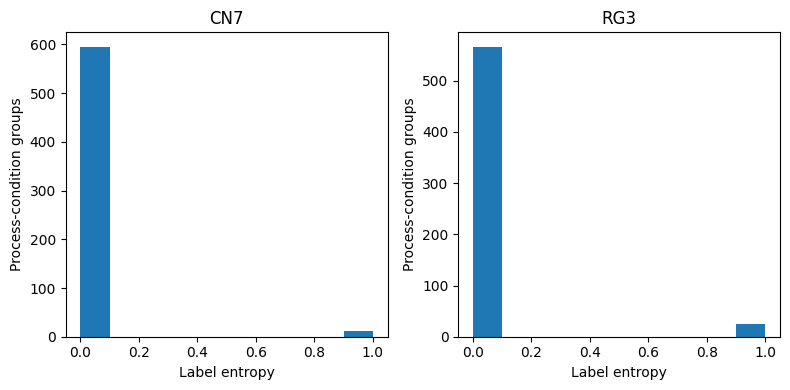

,product,n_groups,conflicting_groups,weighted_conditional_entropy,rows_in_ambiguous_groups_fraction
0,CN7,606,11,0.018167,0.018167
1,RG3,591,25,0.042301,0.042301


In [8]:

# ============================================================
# E1. Label entropy
# ============================================================
def binary_entropy(p):
    p = np.asarray(p, dtype=float)
    out = np.zeros_like(p)
    mask = (p > 0) & (p < 1)
    out[mask] = -(p[mask] * np.log2(p[mask]) + (1-p[mask]) * np.log2(1-p[mask]))
    return out

entropy_summary = []

plt.figure(figsize=(8, 4))

for i, product in enumerate(["CN7", "RG3"], start=1):
    gs = group_summaries[product].copy()
    gs["entropy"] = binary_entropy(gs["p_fail"])
    group_summaries[product] = gs

    weighted_entropy = np.average(gs["entropy"], weights=gs["n"])
    ambiguous_row_fraction = (
        labeled[product]["group_id"].isin(set(gs.loc[gs.entropy > 0, "group_id"])).mean()
    )

    entropy_summary.append({
        "product": product,
        "n_groups": len(gs),
        "conflicting_groups": int((gs.entropy > 0).sum()),
        "weighted_conditional_entropy": float(weighted_entropy),
        "rows_in_ambiguous_groups_fraction": float(ambiguous_row_fraction),
    })

    plt.subplot(1, 2, i)
    plt.hist(gs["entropy"], bins=np.linspace(0, 1, 11))
    plt.title(product)
    plt.xlabel("Label entropy")
    plt.ylabel("Process-condition groups")

plt.tight_layout()
plt.savefig(PLOT_DIR / "E1_label_entropy_cn7_rg3.png", dpi=160)
plt.show()

entropy_summary_df = pd.DataFrame(entropy_summary)
display(entropy_summary_df)
entropy_summary_df.to_csv(OUT_DIR / "E1_entropy_summary.csv", index=False)

for product in ["CN7", "RG3"]:
    group_summaries[product].to_csv(
        OUT_DIR / f"E1_{product.lower()}_group_entropy.csv", index=False
    )


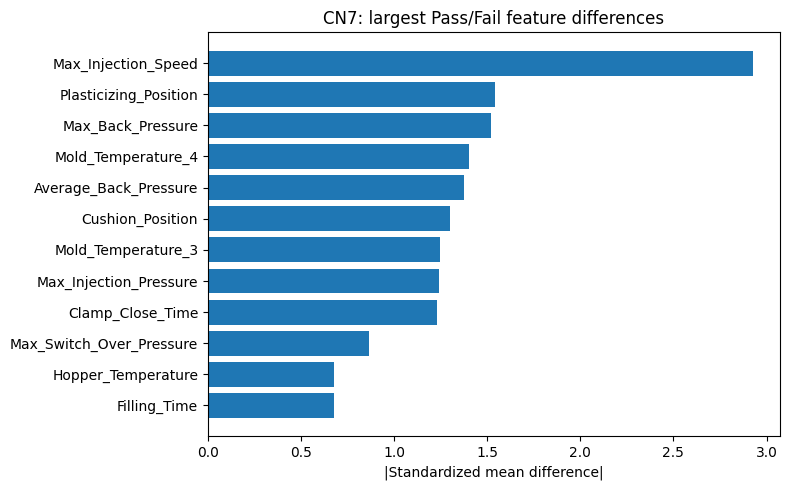

,product,feature,smd_fail_minus_pass,abs_smd
8,CN7,Max_Injection_Speed,2.926190,2.926190
6,CN7,Plasticizing_Position,1.541307,1.541307
13,CN7,Max_Back_Pressure,-1.519006,1.519006
23,CN7,Mold_Temperature_4,1.403715,1.403715
14,CN7,Average_Back_Pressure,-1.376573,1.376573
5,CN7,Cushion_Position,-1.301939,1.301939
22,CN7,Mold_Temperature_3,1.246162,1.246162
11,CN7,Max_Injection_Pressure,-1.238329,1.238329
4,CN7,Clamp_Close_Time,1.228605,1.228605
12,CN7,Max_Switch_Over_Pressure,0.862364,0.862364


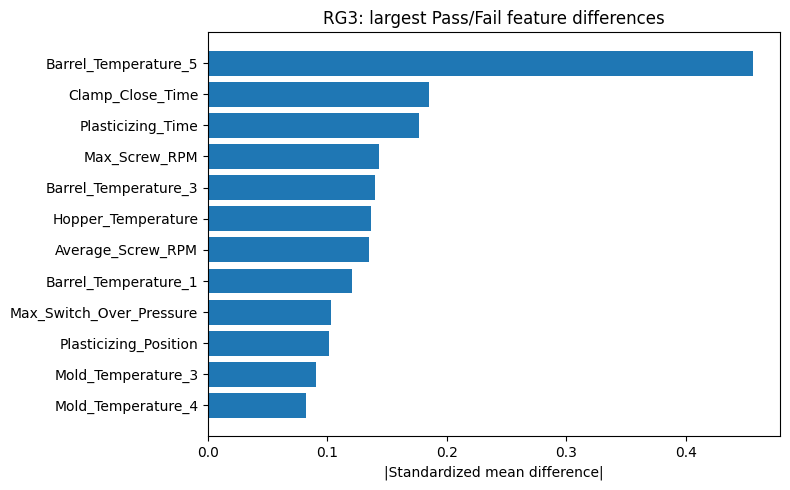

,product,feature,smd_fail_minus_pass,abs_smd
43,RG3,Barrel_Temperature_5,0.455938,0.455938
28,RG3,Clamp_Close_Time,0.184975,0.184975
26,RG3,Plasticizing_Time,0.176601,0.176601
33,RG3,Max_Screw_RPM,0.142899,0.142899
41,RG3,Barrel_Temperature_3,-0.140175,0.140175
45,RG3,Hopper_Temperature,-0.136817,0.136817
34,RG3,Average_Screw_RPM,0.134930,0.134930
39,RG3,Barrel_Temperature_1,-0.120278,0.120278
36,RG3,Max_Switch_Over_Pressure,0.103041,0.103041
30,RG3,Plasticizing_Position,-0.101337,0.101337


In [9]:

# ============================================================
# E1-2. Pass vs Fail feature effect-size EDA
# ============================================================
def standardized_mean_diff(x0, x1):
    x0 = np.asarray(x0, dtype=float)
    x1 = np.asarray(x1, dtype=float)
    x0 = x0[np.isfinite(x0)]
    x1 = x1[np.isfinite(x1)]
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    v0, v1 = np.var(x0, ddof=1), np.var(x1, ddof=1)
    pooled = np.sqrt(((len(x0)-1)*v0 + (len(x1)-1)*v1) / max(len(x0)+len(x1)-2, 1))
    if pooled == 0:
        return 0.0
    return (np.mean(x1) - np.mean(x0)) / pooled

effect_rows = []

for product in ["CN7", "RG3"]:
    df = labeled[product]
    for feat in FEATURES:
        smd = standardized_mean_diff(
            df.loc[df[TARGET] == 0, feat],
            df.loc[df[TARGET] == 1, feat],
        )
        effect_rows.append({
            "product": product,
            "feature": feat,
            "smd_fail_minus_pass": smd,
            "abs_smd": abs(smd) if np.isfinite(smd) else np.nan,
        })

effect_df = pd.DataFrame(effect_rows)
effect_df.to_csv(OUT_DIR / "E1_feature_effect_sizes.csv", index=False)

for product in ["CN7", "RG3"]:
    top = (
        effect_df[effect_df["product"] == product]
        .sort_values("abs_smd", ascending=False)
        .head(12)
        .sort_values("abs_smd")
    )

    plt.figure(figsize=(8, 5))
    plt.barh(top.feature, top.abs_smd)
    plt.xlabel("|Standardized mean difference|")
    plt.title(f"{product}: largest Pass/Fail feature differences")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"E1_{product.lower()}_effect_sizes.png", dpi=160)
    plt.show()

    display(top.sort_values("abs_smd", ascending=False))



# E2/E3. Group-Safe Supervised Prediction + Nested Thresholding + Calibration

### 비교 모델
1. **DummyPrior** — 불량률만 예측하는 명시적 baseline
2. Logistic Regression — 해석 가능한 선형 baseline
3. Random Forest — 비선형/상호작용
4. XGBoost — 강한 tabular model

### 데이터 누수 방지
Outer test fold는 calibration 학습, threshold 선택, model tuning에 사용하지 않습니다.
각 outer fold의 training 부분에서 다시 **inner StratifiedGroupKFold**를 수행합니다.

### 주요 metric
- PR-AUC: 희귀 불량 primary ranking metric
- F1: 평가기준에 명시된 classification metric
- F2: False Negative를 더 강하게 벌주는 safety-oriented metric
- ROC-AUC: 보조
- Brier / ECE: probability calibration


In [10]:

# ============================================================
# E2-0. Imports / models / nested-CV helpers
# ============================================================
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, precision_score, recall_score, f1_score,
    fbeta_score, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

MODEL_NAMES = ["DummyPrior", "Logistic", "RandomForest", "XGBoost"]

def make_model(name, y_train):
    y_train = np.asarray(y_train)

    if name == "DummyPrior":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", DummyClassifier(strategy="prior"))
        ])

    if name == "Logistic":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            ))
        ])

    if name == "RandomForest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced_subsample",
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=SEED,
                n_jobs=-1
            ))
        ])

    if name == "XGBoost":
        if not HAVE_XGB:
            raise RuntimeError("xgboost installation/import failed.")
        pos = max(int(np.sum(y_train == 1)), 1)
        neg = max(int(np.sum(y_train == 0)), 1)
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=250,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                min_child_weight=2,
                scale_pos_weight=neg/pos,
                eval_metric="logloss",
                random_state=SEED,
                n_jobs=-1,
            ))
        ])
    raise ValueError(name)

def safe_auc(y, p):
    try:
        return roc_auc_score(y, p)
    except Exception:
        return np.nan

def expected_calibration_error(y, p, n_bins=CALIBRATION_BINS):
    y=np.asarray(y); p=np.asarray(p)
    bins=np.linspace(0,1,n_bins+1)
    ids=np.digitize(p,bins[1:-1],right=True)
    ece=0.0
    for b in range(n_bins):
        mask=ids==b
        if not np.any(mask):
            continue
        ece += mask.mean()*abs(y[mask].mean()-p[mask].mean())
    return float(ece)

def best_threshold(y, p, beta=1.0):
    precision,recall,th=precision_recall_curve(y,p)
    if len(th)==0:
        return 0.5
    precision=precision[:-1]; recall=recall[:-1]
    beta2=beta**2
    score=(1+beta2)*precision*recall/(beta2*precision+recall+1e-12)
    return float(th[int(np.nanargmax(score))])

def fit_platt(raw_prob, y):
    """
    Fit monotonic Platt-style calibration on inner OOF predictions only.
    If the learned slope is non-positive (unstable/inverted ranking),
    fall back to a constant prevalence calibrator rather than flipping ranking.
    """
    raw_prob=np.clip(np.asarray(raw_prob),1e-6,1-1e-6)
    y=np.asarray(y)
    z=np.log(raw_prob/(1-raw_prob)).reshape(-1,1)
    cal=LogisticRegression(C=1e6,solver="lbfgs",max_iter=2000)
    cal.fit(z,y)
    if float(cal.coef_[0,0]) <= 0:
        return {"mode":"prior","prior":float(y.mean())}
    return {"mode":"logistic","model":cal}

def apply_platt(calibrator, raw_prob):
    raw_prob=np.clip(np.asarray(raw_prob),1e-6,1-1e-6)
    if calibrator["mode"]=="prior":
        return np.full(len(raw_prob),calibrator["prior"],dtype=float)
    z=np.log(raw_prob/(1-raw_prob)).reshape(-1,1)
    return calibrator["model"].predict_proba(z)[:,1]

def inner_oof_raw_predictions(X,y,groups,model_name,seed):
    inner=StratifiedGroupKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=seed
    )
    pred=np.full(len(y),np.nan,dtype=float)
    for itr,iva in inner.split(X,y,groups):
        m=make_model(model_name,y[itr])
        m.fit(X.iloc[itr],y[itr])
        pred[iva]=m.predict_proba(X.iloc[iva])[:,1]
    if np.isnan(pred).any():
        raise RuntimeError("Inner OOF prediction contains NaN.")
    return pred

def nested_repeated_group_cv(df, product):
    X=df[FEATURES].reset_index(drop=True)
    y=df[TARGET].astype(int).to_numpy()
    groups=df["group_id"].astype(str).to_numpy()
    metrics=[]; predictions=[]

    for rep in range(N_REPEATS):
        outer=StratifiedGroupKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=SEED+rep
        )
        for fold,(tr,te) in enumerate(outer.split(X,y,groups),start=1):
            Xtr,Xte=X.iloc[tr],X.iloc[te]
            ytr,yte=y[tr],y[te]
            gtr=groups[tr]

            for model_name in MODEL_NAMES:
                inner_raw=inner_oof_raw_predictions(
                    Xtr.reset_index(drop=True),
                    ytr,
                    gtr,
                    model_name,
                    seed=SEED+1000*rep+10*fold
                )
                calibrator=fit_platt(inner_raw,ytr)
                inner_cal=apply_platt(calibrator,inner_raw)

                # Classification operating thresholds are chosen on RAW inner OOF
                # probabilities. Calibration is evaluated separately.
                th_f1=best_threshold(ytr,inner_raw,beta=1.0)
                th_f2=best_threshold(ytr,inner_raw,beta=2.0)

                m=make_model(model_name,ytr)
                m.fit(Xtr,ytr)
                raw=m.predict_proba(Xte)[:,1]
                cal=apply_platt(calibrator,raw)

                pred_f1=(raw>=th_f1).astype(int)
                pred_f2=(raw>=th_f2).astype(int)

                metrics.append({
                    "product":product,
                    "repeat":rep,
                    "fold":fold,
                    "model":model_name,
                    "n_train":len(tr),
                    "n_test":len(te),
                    "n_fail_test":int(yte.sum()),
                    "test_prevalence":float(yte.mean()),
                    "pr_auc_raw":average_precision_score(yte,raw),
                    "pr_auc_cal":average_precision_score(yte,cal),
                    "roc_auc_cal":safe_auc(yte,cal),
                    "brier_raw":brier_score_loss(yte,raw),
                    "brier_cal":brier_score_loss(yte,cal),
                    "ece_cal":expected_calibration_error(yte,cal),
                    "threshold_f1_inner":th_f1,
                    "threshold_f2_inner":th_f2,
                    "precision_at_f1":precision_score(yte,pred_f1,zero_division=0),
                    "recall_at_f1":recall_score(yte,pred_f1,zero_division=0),
                    "f1":f1_score(yte,pred_f1,zero_division=0),
                    "precision_at_f2":precision_score(yte,pred_f2,zero_division=0),
                    "recall_at_f2":recall_score(yte,pred_f2,zero_division=0),
                    "f2":fbeta_score(yte,pred_f2,beta=2,zero_division=0),
                })

                for idx,pr,pc,pf1,pf2 in zip(te,raw,cal,pred_f1,pred_f2):
                    predictions.append({
                        "product":product,
                        "row_index":int(idx),
                        "repeat":rep,
                        "fold":fold,
                        "model":model_name,
                        "y_true":int(y[idx]),
                        "group_id":groups[idx],
                        "prob_raw":float(pr),
                        "prob_cal":float(pc),
                        "pred_f1":int(pf1),
                        "pred_f2":int(pf2),
                        "threshold_f1":float(th_f1),
                        "threshold_f2":float(th_f2),
                    })
    return pd.DataFrame(metrics),pd.DataFrame(predictions)


In [12]:

# ============================================================
# E2/E3. Nested repeated group-CV execution
# ============================================================
cv_metrics_all=[]; pred_all=[]

for product in ["CN7","RG3"]:
    print("\n================",product,"================")
    fm,pp=nested_repeated_group_cv(labeled[product].reset_index(drop=True),product)
    cv_metrics_all.append(fm)
    pred_all.append(pp)

cv_metrics_df=pd.concat(cv_metrics_all,ignore_index=True)
cv_pred_df=pd.concat(pred_all,ignore_index=True)

cv_metrics_df.to_csv(OUT_DIR/"E2_nested_cv_metrics.csv",index=False)
cv_pred_df.to_csv(OUT_DIR/"E2_nested_oof_predictions.csv",index=False)

summary=(
    cv_metrics_df.groupby(["product","model"])
    .agg(
        n_outer_tests=("pr_auc_raw","size"),
        pr_auc_mean=("pr_auc_raw","mean"),
        pr_auc_std=("pr_auc_raw","std"),
        roc_auc_mean=("roc_auc_cal","mean"),
        f1_mean=("f1","mean"),
        f1_std=("f1","std"),
        f2_mean=("f2","mean"),
        recall_f2_mean=("recall_at_f2","mean"),
        precision_f2_mean=("precision_at_f2","mean"),
        brier_mean=("brier_cal","mean"),
        ece_mean=("ece_cal","mean"),
    ).reset_index()
)
summary["pr_auc_ci95"]=1.96*summary["pr_auc_std"]/np.sqrt(summary["n_outer_tests"])
summary["f1_ci95"]=1.96*summary["f1_std"]/np.sqrt(summary["n_outer_tests"])

baseline=(
    summary[summary["model"]=="DummyPrior"]
    [["product","pr_auc_mean","f1_mean"]]
    .rename(columns={"pr_auc_mean":"baseline_pr_auc","f1_mean":"baseline_f1"})
)
summary=summary.merge(baseline,on="product",how="left")
summary["pr_auc_gain_vs_baseline"]=summary.pr_auc_mean-summary.baseline_pr_auc
summary["f1_gain_vs_baseline"]=summary.f1_mean-summary.baseline_f1

candidate_summary=summary[summary.model!="DummyPrior"].copy()
candidate_summary=candidate_summary.sort_values(
    ["product","pr_auc_mean","f1_mean","brier_mean"],
    ascending=[True,False,False,True]
)
best_model_by_product=(
    candidate_summary.groupby("product").first()["model"].to_dict()
)

display(summary.sort_values(["product","pr_auc_mean"],ascending=[True,False]))
summary.to_csv(OUT_DIR/"E2_model_comparison_nested.csv",index=False)

selection_rows=[]
for product in ["CN7","RG3"]:
    chosen = candidate_summary[
    candidate_summary["product"] == product
].iloc[0]

base = summary[
    (summary["product"] == product) &
    (summary["model"] == "DummyPrior")
].iloc[0]
    selection_rows.append({
        "product":product,
        "selected_model":chosen.model,
        "selection_primary":"mean PR-AUC under nested repeated group-CV",
        "tie_break_1":"mean F1 with inner-CV threshold",
        "tie_break_2":"lower calibrated Brier score",
        "selected_pr_auc":chosen.pr_auc_mean,
        "selected_f1":chosen.f1_mean,
        "selected_f2":chosen.f2_mean,
        "baseline_pr_auc":base.pr_auc_mean,
        "pr_auc_gain_vs_baseline":chosen.pr_auc_mean-base.pr_auc_mean,
        "baseline_f1":base.f1_mean,
        "f1_gain_vs_baseline":chosen.f1_mean-base.f1_mean,
    })

model_selection_df=pd.DataFrame(selection_rows)
model_selection_df.to_csv(OUT_DIR/"E2_final_model_selection.csv",index=False)
display(model_selection_df)
print("Selected:",best_model_by_product)


IndentationError: unexpected indent (1475419050.py, line 68)

In [ ]:

# ============================================================
# E2-2. Repeated outer-test prediction aggregation + calibration plot
# ============================================================
oof_avg=(
    cv_pred_df.groupby(["product","row_index","model","y_true","group_id"])
    .agg(
        prob_raw_mean=("prob_raw","mean"),
        prob_raw_std=("prob_raw","std"),
        prob_cal_mean=("prob_cal","mean"),
        prob_cal_std=("prob_cal","std"),
        pred_f1_rate=("pred_f1","mean"),
        pred_f2_rate=("pred_f2","mean"),
        n_predictions=("prob_cal","size"),
    ).reset_index()
)
oof_avg["pred_f1_majority"]=(oof_avg.pred_f1_rate>=0.5).astype(int)
oof_avg["pred_f2_majority"]=(oof_avg.pred_f2_rate>=0.5).astype(int)
oof_avg.to_csv(OUT_DIR/"E2_oof_average_predictions.csv",index=False)

best_oof=[]
for product in ["CN7","RG3"]:
    model=best_model_by_product[product]
    tmp=oof_avg[
        (oof_avg["product"]==product)&(oof_avg["model"]==model)
    ].copy()
    tmp["best_model"]=model
    best_oof.append(tmp)
best_oof_df=pd.concat(best_oof,ignore_index=True)
best_oof_df.to_csv(OUT_DIR/"E2_best_model_oof_predictions.csv",index=False)

plt.figure(figsize=(7,5))
for product in ["CN7","RG3"]:
    tmp=best_oof_df[best_oof_df["product"]==product]
    precision,recall,_=precision_recall_curve(tmp.y_true,tmp.prob_raw_mean)
    ap=average_precision_score(tmp.y_true,tmp.prob_raw_mean)
    plt.plot(recall,precision,label=f"{product} AP={ap:.3f}")
    plt.axhline(tmp.y_true.mean(),linestyle="--",alpha=.5)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Nested group-CV precision-recall curves")
plt.legend(); plt.tight_layout()
plt.savefig(PLOT_DIR/"E2_best_model_pr_curves.png",dpi=160)
plt.show()

calibration_rows=[]
for product in ["CN7","RG3"]:
    tmp=best_oof_df[best_oof_df["product"]==product]
    frac_pos,mean_pred=calibration_curve(
        tmp.y_true,tmp.prob_raw_mean,n_bins=CALIBRATION_BINS,strategy="quantile"
    )
    for fp,mp in zip(frac_pos,mean_pred):
        calibration_rows.append({
            "product":product,
            "mean_predicted_probability":mp,
            "observed_failure_fraction":fp
        })

calibration_df=pd.DataFrame(calibration_rows)
calibration_df.to_csv(OUT_DIR/"E3_calibration_curve.csv",index=False)

plt.figure(figsize=(6,6))
for product in ["CN7","RG3"]:
    t=calibration_df[calibration_df.product==product]
    plt.plot(t.mean_predicted_probability,t.observed_failure_fraction,marker="o",label=product)
plt.plot([0,1],[0,1],linestyle="--",label="perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed failure fraction")
plt.title("Cross-fitted probability calibration")
plt.legend(); plt.tight_layout()
plt.savefig(PLOT_DIR/"E3_reliability_diagram.png",dpi=160)
plt.show()



# E4. Failure Condition Analysis

모델 실패를 세 종류로 나눕니다.

1. **Label conflict:** 같은 공정조건에서 Pass/Fail이 섞임
2. **Sparse region:** training/labeled distribution에서 희귀한 영역
3. **Model error:** 정보가 있어도 모델이 잘못 예측

아래에서는 best-model OOF risk와 kNN distance를 이용해 분석합니다.


In [ ]:

# ============================================================
# E4-1. FN/FP analysis using leakage-free inner-CV F2 decisions
# ============================================================
failure_rows=[]

for product in ["CN7","RG3"]:
    base=labeled[product].reset_index(drop=True).copy()
    pred=best_oof_df[best_oof_df["product"]==product].set_index("row_index")

    base["oof_prob"]=[pred.loc[i,"prob_raw_mean"] for i in range(len(base))]
    base["oof_uncertainty"]=[pred.loc[i,"prob_cal_std"] for i in range(len(base))]
    base["pred_f1"]=[pred.loc[i,"pred_f1_majority"] for i in range(len(base))]
    base["pred_f2"]=[pred.loc[i,"pred_f2_majority"] for i in range(len(base))]

    def error_type(r):
        if r[TARGET]==1 and r.pred_f2==1: return "TP"
        if r[TARGET]==1 and r.pred_f2==0: return "FN"
        if r[TARGET]==0 and r.pred_f2==1: return "FP"
        return "TN"

    base["error_type"]=base.apply(error_type,axis=1)

    conflict_groups=set(
        group_summaries[product].loc[
            group_summaries[product]["conflict"]==1,"group_id"
        ]
    )
    base["conflicting_group"]=base.group_id.isin(conflict_groups).astype(int)

    imp=SimpleImputer(strategy="median")
    sc=StandardScaler()
    Xs=sc.fit_transform(imp.fit_transform(base[FEATURES]))
    k=min(11,len(base))
    nbr=NearestNeighbors(n_neighbors=k).fit(Xs)
    distances,_=nbr.kneighbors(Xs)
    base["knn_rarity"]=distances[:,1:].mean(axis=1)
    q90=base["knn_rarity"].quantile(.90)
    base["sparse_region"]=(base["knn_rarity"]>=q90).astype(int)

    base["product"]=product
    failure_rows.append(base)

failure_df=pd.concat(failure_rows,ignore_index=True)
failure_df.to_csv(OUT_DIR/"E4_failure_analysis_rows.csv",index=False)

error_summary=(
    failure_df.groupby(["product","error_type"])
    .agg(
        n=("error_type","size"),
        mean_prob=("oof_prob","mean"),
        conflict_rate=("conflicting_group","mean"),
        sparse_rate=("sparse_region","mean"),
        mean_rarity=("knn_rarity","mean"),
    ).reset_index()
)
display(error_summary)
error_summary.to_csv(OUT_DIR/"E4_error_summary.csv",index=False)


In [ ]:

# ============================================================
# E4-2. FN/FP concentrated process-condition bins
# ============================================================
condition_rows=[]

for product in ["CN7","RG3"]:
    sub=failure_df[failure_df["product"]==product].copy()

    for feat in FEATURES:
        try:
            bins=pd.qcut(sub[feat],q=4,duplicates="drop")
        except Exception:
            continue

        tmp=pd.DataFrame({
            "bin":bins.astype(str),
            "y":sub[TARGET].values,
            "err":sub.error_type.values
        })

        for b,g in tmp.groupby("bin"):
            n_fail=int((g.y==1).sum())
            n_pass=int((g.y==0).sum())
            fn=int((g.err=="FN").sum())
            fp=int((g.err=="FP").sum())
            condition_rows.append({
                "product":product,
                "feature":feat,
                "condition_bin":b,
                "n":len(g),
                "n_actual_fail":n_fail,
                "n_actual_pass":n_pass,
                "FN":fn,
                "FP":fp,
                "FN_rate_among_fail":fn/n_fail if n_fail else np.nan,
                "FP_rate_among_pass":fp/n_pass if n_pass else np.nan,
                "observed_fail_rate":n_fail/len(g) if len(g) else np.nan,
            })

error_condition_bins_df=pd.DataFrame(condition_rows)
error_condition_bins_df.to_csv(
    OUT_DIR/"E4_FN_FP_concentrated_conditions.csv",index=False
)

print("Top FN-concentrated bins (minimum 2 actual fails):")
display(
    error_condition_bins_df[error_condition_bins_df.n_actual_fail>=2]
    .sort_values(
        ["product","FN_rate_among_fail","n_actual_fail"],
        ascending=[True,False,False]
    ).groupby("product").head(12)
)

print("Top FP-concentrated bins (minimum 20 actual passes):")
display(
    error_condition_bins_df[error_condition_bins_df.n_actual_pass>=20]
    .sort_values(
        ["product","FP_rate_among_pass","n_actual_pass"],
        ascending=[True,False,False]
    ).groupby("product").head(12)
)

failure_feature_rows=[]
for product in ["CN7","RG3"]:
    sub=failure_df[failure_df["product"]==product]
    for feat in FEATURES:
        for err in ["FN","FP","TP","TN"]:
            vals=sub.loc[sub.error_type==err,feat]
            failure_feature_rows.append({
                "product":product,
                "feature":feat,
                "error_type":err,
                "n":int(vals.notna().sum()),
                "mean":float(vals.mean()) if vals.notna().any() else np.nan,
                "median":float(vals.median()) if vals.notna().any() else np.nan,
            })

failure_feature_df=pd.DataFrame(failure_feature_rows)
failure_feature_df.to_csv(
    OUT_DIR/"E4_error_condition_feature_summary.csv",index=False
)



# E4-3. Permutation Importance

Best supervised model을 전체 labeled data에 학습한 뒤 permutation importance를 봅니다.

**주의:** 이것은 feature association / predictive importance이지 인과효과가 아닙니다.


In [ ]:

# ============================================================
# E4-3. Held-out fold permutation importance
# ============================================================
perm_rows = []
fitted_best_models = {}

for product in ["CN7", "RG3"]:
    df = labeled[product].reset_index(drop=True)
    X = df[FEATURES]
    y = df[TARGET].astype(int).values
    groups = df.group_id.astype(str).values

    best_name = best_model_by_product[product]

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=SEED + 777
    )

    fold_importances = []

    for fold,(tr,te) in enumerate(cv.split(X,y,groups),1):
        model = make_model(best_name, y[tr])
        model.fit(X.iloc[tr], y[tr])

        r = permutation_importance(
            model,
            X.iloc[te],
            y[te],
            scoring="average_precision",
            n_repeats=10,
            random_state=SEED + fold,
            n_jobs=-1
        )

        for feat,mean,std in zip(FEATURES,r.importances_mean,r.importances_std):
            perm_rows.append({
                "product":product,
                "model":best_name,
                "fold":fold,
                "feature":feat,
                "importance_mean":mean,
                "importance_std_within_fold":std
            })

    # 최종 export용 전체-data 모델
    full_model = make_model(best_name, y)
    full_model.fit(X,y)
    fitted_best_models[product] = full_model

perm_fold_df = pd.DataFrame(perm_rows)
perm_fold_df.to_csv(
    OUT_DIR / "E4_permutation_importance_by_fold.csv",
    index=False
)

perm_df = (
    perm_fold_df
    .groupby(["product","model","feature"])
    .agg(
        importance_mean=("importance_mean","mean"),
        importance_std=("importance_mean","std")
    )
    .reset_index()
)

perm_df.to_csv(OUT_DIR / "E4_permutation_importance.csv", index=False)

for product in ["CN7","RG3"]:
    psub = (
        perm_df[perm_df["product"]==product]
        .sort_values("importance_mean",ascending=False)
    )
    display(psub.head(12))

    top = psub.head(12).sort_values("importance_mean")
    plt.figure(figsize=(8,5))
    plt.barh(top.feature, top.importance_mean)
    plt.xlabel("Held-out permutation importance (AP decrease)")
    plt.title(f"{product}: cross-validated predictive importance")
    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"E4_{product.lower()}_cv_permutation_importance.png",
        dpi=160
    )
    plt.show()



# E4-4. PDP / SHAP (해석 보조)

- **PDP:** 상위 predictive feature의 값 변화와 모델 risk score의 관계
- **SHAP:** 개별 샘플의 예측을 어떤 feature가 밀어 올리고/내렸는지 확인

이 결과는 **인과효과가 아니라 모델 내부의 predictive association**입니다.


In [ ]:

# ============================================================
# E4-4. PDP / SHAP / interaction analysis
# ============================================================
from sklearn.inspection import PartialDependenceDisplay

interaction_rows=[]
shap_summaries=[]

for product in ["CN7","RG3"]:
    top_features=(
        perm_df[perm_df["product"]==product]
        .sort_values("importance_mean",ascending=False)
        .head(4).feature.tolist()
    )

    model=fitted_best_models[product]
    X=labeled[product][FEATURES]

    if top_features:
        fig,axes=plt.subplots(len(top_features),1,figsize=(9,3*len(top_features)))
        axes=np.atleast_1d(axes)
        for ax,feat in zip(axes,top_features):
            PartialDependenceDisplay.from_estimator(model,X,[feat],ax=ax)
            ax.set_title(f"{product}: PDP — {feat}")
        plt.tight_layout()
        plt.savefig(PLOT_DIR/f"E4_{product.lower()}_pdp_top_features.png",dpi=160)
        plt.show()

    pairs=[]
    for i in range(min(3,len(top_features))):
        for j in range(i+1,min(3,len(top_features))):
            pairs.append((top_features[i],top_features[j]))

    for a,b in pairs:
        fig,ax=plt.subplots(figsize=(6,5))
        PartialDependenceDisplay.from_estimator(model,X,[(a,b)],kind="average",ax=ax)
        ax.set_title(f"{product}: 2D PDP — {a} × {b}")
        plt.tight_layout()
        safe_a=re.sub(r"[^A-Za-z0-9]+","_",a)
        safe_b=re.sub(r"[^A-Za-z0-9]+","_",b)
        plt.savefig(
            PLOT_DIR/f"E4_{product.lower()}_interaction_{safe_a}_{safe_b}.png",
            dpi=160
        )
        plt.show()

if RUN_SHAP:
    try:
        import subprocess
        subprocess.check_call([sys.executable,"-m","pip","install","-q","shap"])
        import shap

        for product in ["CN7","RG3"]:
            pipe=fitted_best_models[product]
            Xraw=labeled[product][FEATURES].copy()

            imputer=pipe.named_steps.get("imputer") if hasattr(pipe,"named_steps") else None
            scaler=pipe.named_steps.get("scaler") if hasattr(pipe,"named_steps") else None
            clf=pipe.named_steps.get("clf") if hasattr(pipe,"named_steps") else pipe

            Xt=imputer.transform(Xraw) if imputer is not None else Xraw.values
            if scaler is not None:
                Xt=scaler.transform(Xt)

            if clf.__class__.__name__ not in ["RandomForestClassifier","XGBClassifier"]:
                print(product,": selected model is not tree-based; SHAP interaction skipped.")
                continue

            n_sample=min(300,len(Xraw))
            rng=np.random.RandomState(SEED)
            idx=rng.choice(len(Xraw),size=n_sample,replace=False)
            Xs=Xt[idx]

            explainer=shap.TreeExplainer(clf)
            sv=explainer.shap_values(Xs)

            if isinstance(sv,list):
                vals=np.asarray(sv[-1])
            else:
                vals=np.asarray(sv)
                if vals.ndim==3:
                    vals=vals[:,:,1]

            mean_abs=np.abs(vals).mean(axis=0)
            s=pd.DataFrame({
                "product":product,
                "feature":FEATURES,
                "mean_abs_shap":mean_abs
            }).sort_values("mean_abs_shap",ascending=False)
            shap_summaries.append(s)

            try:
                siv=explainer.shap_interaction_values(Xs)
                if isinstance(siv,list):
                    iv=np.asarray(siv[-1])
                else:
                    iv=np.asarray(siv)
                    if iv.ndim==4:
                        iv=iv[:,:,:,1]

                mean_inter=np.abs(iv).mean(axis=0)
                np.fill_diagonal(mean_inter,0.0)
                for i in range(len(FEATURES)):
                    for j in range(i+1,len(FEATURES)):
                        interaction_rows.append({
                            "product":product,
                            "feature_1":FEATURES[i],
                            "feature_2":FEATURES[j],
                            "mean_abs_shap_interaction":float(mean_inter[i,j])
                        })
            except Exception as e:
                print(product,"SHAP interaction skipped:",repr(e))

        if shap_summaries:
            pd.concat(shap_summaries,ignore_index=True).to_csv(
                OUT_DIR/"E4_shap_feature_summary.csv",index=False
            )
        if interaction_rows:
            interaction_df=pd.DataFrame(interaction_rows).sort_values(
                ["product","mean_abs_shap_interaction"],
                ascending=[True,False]
            )
            interaction_df.to_csv(
                OUT_DIR/"E4_shap_interactions.csv",index=False
            )
            display(interaction_df.groupby("product").head(15))
    except Exception as e:
        print("SHAP skipped due to environment/version issue:",repr(e))
else:
    print("RUN_SHAP=False: SHAP skipped")



## E4-5. 상위 두 변수의 공정조건 조합별 불량/FN/FP

Cross-validated permutation importance 상위 두 변수의 3×3 조건 grid를 자동 생성합니다.


In [ ]:

# ============================================================
# E4-5. Top-two feature condition grid
# ============================================================
grid_rows=[]

for product in ["CN7","RG3"]:
    tops=(
        perm_df[perm_df["product"]==product]
        .sort_values("importance_mean",ascending=False)
        .head(2).feature.tolist()
    )
    if len(tops)<2:
        continue
    f1,f2=tops
    sub=failure_df[failure_df.product==product].copy()

    try:
        sub["bin_1"]=pd.qcut(sub[f1],q=3,duplicates="drop").astype(str)
        sub["bin_2"]=pd.qcut(sub[f2],q=3,duplicates="drop").astype(str)
    except Exception:
        continue

    for (b1,b2),g in sub.groupby(["bin_1","bin_2"]):
        n_fail=int((g[TARGET]==1).sum())
        n_pass=int((g[TARGET]==0).sum())
        fn=int((g.error_type=="FN").sum())
        fp=int((g.error_type=="FP").sum())
        grid_rows.append({
            "product":product,
            "feature_1":f1,
            "feature_2":f2,
            "bin_1":b1,
            "bin_2":b2,
            "n":len(g),
            "fail_rate":float((g[TARGET]==1).mean()),
            "FN_rate_among_fail":fn/n_fail if n_fail else np.nan,
            "FP_rate_among_pass":fp/n_pass if n_pass else np.nan,
        })

interaction_condition_df=pd.DataFrame(grid_rows)
interaction_condition_df.to_csv(
    OUT_DIR/"E4_interaction_condition_grid.csv",index=False
)
display(interaction_condition_df)



# E5. Risk-Based Inspection: Recall@Top-K / Lift@K

모델이 높은 risk부터 검사한다고 가정합니다.

\[
Recall@K = \frac{\text{Top K에서 발견한 Fail}}{\text{전체 Fail}}
\]

\[
Lift@K = \frac{Recall@K}{K}
\]

예: 상위 10% 검사로 Fail 60%를 찾으면 Lift@10% = 6.


In [ ]:

# ============================================================
# E5. Recall@TopK / Lift
# ============================================================
ranking_rows = []

for product in ["CN7", "RG3"]:
    sub = best_oof_df[best_oof_df["product"] == product].copy()
    sub = sub.sort_values("prob_raw_mean", ascending=False)
    total_fail = int(sub.y_true.sum())
    n = len(sub)

    for frac in TOP_K_PCTS:
        k = max(1, int(math.ceil(n * frac)))
        picked = sub.head(k)
        captured = int(picked.y_true.sum())
        recall_at_k = captured / total_fail if total_fail else np.nan
        lift = recall_at_k / frac if frac > 0 else np.nan

        ranking_rows.append({
            "product": product,
            "inspection_fraction": frac,
            "n_inspected": k,
            "fail_captured": captured,
            "total_fail": total_fail,
            "recall_at_k": recall_at_k,
            "lift_at_k": lift,
        })

ranking_df = pd.DataFrame(ranking_rows)
display(ranking_df)
ranking_df.to_csv(OUT_DIR / "E5_recall_lift_topk.csv", index=False)

plt.figure(figsize=(7,5))
for product in ["CN7", "RG3"]:
    t = ranking_df[ranking_df["product"] == product]
    plt.plot(t.inspection_fraction, t.recall_at_k, marker="o", label=product)

plt.plot([0, 0.5], [0, 0.5], linestyle="--", label="random inspection")
plt.xlabel("Fraction inspected")
plt.ylabel("Fraction of defects captured")
plt.title("Risk-based inspection efficiency")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "E5_inspection_recall_curve.png", dpi=160)
plt.show()



# E6. Selective Classification / Uncertainty-Aware Inspection

AI가 모든 제품을 자동 판정하지 않고:
- 낮은 risk → 자동 Pass
- 높은 risk → 검사
- 높은 uncertainty → 검사

로 보냅니다.

Repeated CV prediction의 평균과 표준편차를 사용합니다.


In [ ]:

# ============================================================
# E6. Risk + uncertainty triage
# ============================================================
triage_rows = []

for product in ["CN7", "RG3"]:
    sub = best_oof_df[best_oof_df["product"] == product].copy()

    # normalize risk / uncertainty 0..1
    def minmax(s):
        lo, hi = float(s.min()), float(s.max())
        if hi <= lo:
            return np.zeros(len(s))
        return (s - lo) / (hi - lo)

    sub["risk_norm"] = minmax(sub["prob_raw_mean"])
    sub["unc_norm"] = minmax(sub["prob_raw_std"].fillna(0))
    sub["triage_score"] = sub["risk_norm"] + 0.5 * sub["unc_norm"]

    total_fail = int(sub.y_true.sum())

    for inspect_frac in [0.05,0.10,0.20,0.30,0.40,0.50]:
        n_inspect = max(1, int(math.ceil(len(sub) * inspect_frac)))

        for strategy in ["risk_only", "risk_plus_uncertainty"]:
            score_col = "prob_raw_mean" if strategy == "risk_only" else "triage_score"
            inspected = sub.nlargest(n_inspect, score_col)
            auto_pass = sub.drop(inspected.index)

            captured = int(inspected.y_true.sum())
            escaped = int(auto_pass.y_true.sum())

            triage_rows.append({
                "product": product,
                "strategy": strategy,
                "inspection_fraction": inspect_frac,
                "n_inspected": n_inspect,
                "defects_captured": captured,
                "defects_escaped_auto_pass": escaped,
                "capture_recall": captured / total_fail if total_fail else np.nan,
                "auto_pass_defect_rate": auto_pass.y_true.mean() if len(auto_pass) else np.nan,
            })

triage_df = pd.DataFrame(triage_rows)
triage_df.to_csv(OUT_DIR / "E6_selective_classification.csv", index=False)
display(triage_df.head(20))

for product in ["CN7","RG3"]:
    plt.figure(figsize=(7,5))
    for strategy in ["risk_only","risk_plus_uncertainty"]:
        t = triage_df[(triage_df["product"]==product)&(triage_df.strategy==strategy)]
        plt.plot(t.inspection_fraction, t.capture_recall, marker="o", label=strategy)
    plt.xlabel("Inspection fraction")
    plt.ylabel("Defect capture recall")
    plt.title(f"{product}: selective inspection")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"E6_{product.lower()}_selective_inspection.png", dpi=160)
    plt.show()



# E7. Labeled vs Unlabeled Distribution Audit

71,180개의 unlabeled 데이터가 labeled와 같은 분포인지 먼저 확인합니다.

새 target:
- 0 = labeled
- 1 = unlabeled

이 분류가 잘 되면, labeled와 unlabeled가 서로 다른 domain일 가능성이 큽니다.


In [ ]:

# ============================================================
# E7. Domain classifier with exact-group-safe CV
# ============================================================
domain_rows = []

for product in ["CN7","RG3"]:
    lab = labeled[product][FEATURES + ["group_id"]].copy()
    lab["domain"] = 0

    unlab = unlabeled[product][FEATURES + ["group_id"]].copy()
    unlab["domain"] = 1

    sample_n = min(len(lab), len(unlab))

    aucs = []
    sep_aucs = []

    for rep in range(5):
        us = unlab.sample(sample_n, random_state=SEED+rep)
        ds = pd.concat([lab, us], ignore_index=True)

        X = ds[FEATURES]
        y = ds["domain"].astype(int).values
        groups = ds["group_id"].astype(str).values

        cv = StratifiedGroupKFold(
            n_splits=4,
            shuffle=True,
            random_state=SEED+100+rep
        )

        pred = np.zeros(len(ds), dtype=float)

        for tr,te in cv.split(X,y,groups):
            m = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced"
                ))
            ])
            m.fit(X.iloc[tr],y[tr])
            pred[te] = m.predict_proba(X.iloc[te])[:,1]

        auc = roc_auc_score(y,pred)
        # AUC의 방향이 반대로 뒤집혀도 분리 가능성은 동일하므로 symmetric AUC 사용
        sep_auc = max(auc, 1.0-auc)

        aucs.append(auc)
        sep_aucs.append(sep_auc)

        domain_rows.append({
            "product":product,
            "repeat":rep,
            "roc_auc_raw":auc,
            "separability_auc":sep_auc
        })

    print(
        product,
        "raw AUC:",np.mean(aucs),
        "| symmetric separability AUC:",np.mean(sep_aucs),
        "+/-",np.std(sep_aucs)
    )

domain_df = pd.DataFrame(domain_rows)
domain_df.to_csv(
    OUT_DIR / "E7_labeled_vs_unlabeled_domain_auc.csv",
    index=False
)

display(
    domain_df.groupby("product").separability_auc.agg(["mean","std"])
)



# E8-A. One-Class / Anomaly Detection

불량 label을 직접 학습하지 않고 **정상(Pass) 분포**만 학습합니다.

비교:
- Mahalanobis distance (Ledoit-Wolf covariance)
- Isolation Forest

각 fold의 training Pass만 사용하고 test 전체를 평가합니다.


In [ ]:

# ============================================================
# E8-A. One-class group-safe CV
# ============================================================
def mahalanobis_scores(X_train_pass, X_test):
    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()

    A = sc.fit_transform(imp.fit_transform(X_train_pass))
    B = sc.transform(imp.transform(X_test))

    cov = LedoitWolf().fit(A)
    # sklearn mahalanobis: quadratic form
    delta = B - cov.location_
    scores = np.einsum("ij,jk,ik->i", delta, cov.precision_, delta)
    return scores

oneclass_rows = []
oneclass_pred_rows = []

for product in ["CN7","RG3"]:
    df = labeled[product].reset_index(drop=True)
    X = df[FEATURES]
    y = df[TARGET].astype(int).values
    groups = df.group_id.astype(str).values

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=SEED
    )

    for fold,(tr,te) in enumerate(cv.split(X,y,groups),1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]

        pass_mask = ytr == 0
        Xpass = Xtr.iloc[np.where(pass_mask)[0]]

        # Mahalanobis
        maha = mahalanobis_scores(Xpass, Xte)
        ap = average_precision_score(yte, maha)
        auc = safe_auc(yte, maha)
        oneclass_rows.append({
            "product":product,"fold":fold,"method":"Mahalanobis",
            "pr_auc":ap,"roc_auc":auc
        })
        for idx,s in zip(te,maha):
            oneclass_pred_rows.append({
                "product":product,"row_index":int(idx),"fold":fold,
                "method":"Mahalanobis","y_true":int(y[idx]),"score":float(s)
            })

        # Isolation Forest
        imp = SimpleImputer(strategy="median")
        sc = StandardScaler()
        A = sc.fit_transform(imp.fit_transform(Xpass))
        B = sc.transform(imp.transform(Xte))

        iso = IsolationForest(
            n_estimators=500,
            contamination="auto",
            random_state=SEED+fold,
            n_jobs=-1
        )
        iso.fit(A)
        # 높을수록 anomaly
        score = -iso.score_samples(B)

        ap = average_precision_score(yte, score)
        auc = safe_auc(yte, score)
        oneclass_rows.append({
            "product":product,"fold":fold,"method":"IsolationForest",
            "pr_auc":ap,"roc_auc":auc
        })
        for idx,s in zip(te,score):
            oneclass_pred_rows.append({
                "product":product,"row_index":int(idx),"fold":fold,
                "method":"IsolationForest","y_true":int(y[idx]),"score":float(s)
            })

oneclass_df = pd.DataFrame(oneclass_rows)
oneclass_pred_df = pd.DataFrame(oneclass_pred_rows)

oneclass_df.to_csv(OUT_DIR / "E8_oneclass_cv_metrics.csv", index=False)
oneclass_pred_df.to_csv(OUT_DIR / "E8_oneclass_predictions.csv", index=False)

display(
    oneclass_df.groupby(["product","method"]).agg(
        pr_auc_mean=("pr_auc","mean"),
        pr_auc_std=("pr_auc","std"),
        roc_auc_mean=("roc_auc","mean")
    )
)



# E8-B. Unlabeled Representation Learning — PCA

가장 안정적인 baseline으로 unlabeled 데이터에서 PCA representation을 학습하고,
그 latent feature로 labeled defect prediction을 수행합니다.

Autoencoder는 다음 셀에서 선택적으로 수행합니다.


In [ ]:

# ============================================================
# E8-B1. PCA representation from unlabeled data
# ============================================================
pca_rows = []

for product in ["CN7","RG3"]:
    U = unlabeled[product][FEATURES].copy()
    L = labeled[product].reset_index(drop=True).copy()

    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()

    U_s = sc.fit_transform(imp.fit_transform(U))
    L_s = sc.transform(imp.transform(L[FEATURES]))

    n_comp = min(12, len(FEATURES))
    pca = PCA(n_components=n_comp, random_state=SEED)
    pca.fit(U_s)

    Z = pca.transform(L_s)
    zcols = [f"PC{i+1}" for i in range(Z.shape[1])]
    zdf = pd.DataFrame(Z, columns=zcols)
    zdf["PassOrFail"] = L[TARGET].values
    zdf["group_id"] = L.group_id.values

    X = zdf[zcols]
    y = zdf[TARGET].astype(int).values
    groups = zdf.group_id.astype(str).values

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=SEED
    )
    pred = np.zeros(len(zdf))

    for tr,te in cv.split(X,y,groups):
        clf = LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=SEED
        )
        clf.fit(X.iloc[tr], y[tr])
        pred[te] = clf.predict_proba(X.iloc[te])[:,1]

    pca_rows.append({
        "product":product,
        "n_components":n_comp,
        "explained_variance":float(pca.explained_variance_ratio_.sum()),
        "pr_auc":average_precision_score(y,pred),
        "roc_auc":safe_auc(y,pred),
        "brier":brier_score_loss(y,pred),
    })

pca_df = pd.DataFrame(pca_rows)
pca_df.to_csv(OUT_DIR / "E8_pca_representation_results.csv", index=False)
display(pca_df)



# E8-C. Unlabeled Autoencoder Representation (optional)

PyTorch autoencoder를 **unlabeled 데이터만으로** 학습한 뒤 latent vector를 defect classifier에 사용합니다.

- unlabeled → representation pretraining
- labeled → group-safe classifier evaluation

데이터 분포가 크게 다르면(E7 Domain AUC가 매우 높으면) 해석에 주의하세요.


In [ ]:

# ============================================================
# E8-C. Autoencoder representation
# ============================================================
if RUN_AUTOENCODER:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("AE device:", device)

    class AE(nn.Module):
        def __init__(self, d_in, latent):
            super().__init__()
            hidden = max(12, d_in)
            self.encoder = nn.Sequential(
                nn.Linear(d_in, hidden),
                nn.ReLU(),
                nn.Linear(hidden, latent),
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent, hidden),
                nn.ReLU(),
                nn.Linear(hidden, d_in),
            )
        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z)

    ae_results = []

    for product in ["CN7","RG3"]:
        print("\nAE:", product)
        U = unlabeled[product][FEATURES]
        L = labeled[product].reset_index(drop=True)

        imp = SimpleImputer(strategy="median")
        sc = StandardScaler()

        U_s = sc.fit_transform(imp.fit_transform(U)).astype("float32")
        L_s = sc.transform(imp.transform(L[FEATURES])).astype("float32")

        ds = TensorDataset(torch.tensor(U_s))
        dl = DataLoader(ds, batch_size=AE_BATCH, shuffle=True)

        model = AE(U_s.shape[1], AE_LATENT).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        for epoch in range(AE_EPOCHS):
            model.train()
            total = 0.0
            for (xb,) in dl:
                xb = xb.to(device)
                opt.zero_grad()
                recon = model(xb)
                loss = loss_fn(recon, xb)
                loss.backward()
                opt.step()
                total += float(loss.item()) * len(xb)
            if epoch in [0, AE_EPOCHS-1] or (epoch+1) % 5 == 0:
                print(f"epoch {epoch+1:02d}: loss={total/len(ds):.6f}")

        model.eval()
        with torch.no_grad():
            Z = model.encoder(torch.tensor(L_s).to(device)).cpu().numpy()

        zcols = [f"AE{i+1}" for i in range(Z.shape[1])]
        Xz = pd.DataFrame(Z, columns=zcols)
        y = L[TARGET].astype(int).values
        groups = L.group_id.astype(str).values

        cv = StratifiedGroupKFold(
            n_splits=N_SPLITS, shuffle=True, random_state=SEED
        )
        pred = np.zeros(len(L))

        for tr,te in cv.split(Xz,y,groups):
            clf = LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
            clf.fit(Xz.iloc[tr],y[tr])
            pred[te] = clf.predict_proba(Xz.iloc[te])[:,1]

        ae_results.append({
            "product":product,
            "latent_dim":AE_LATENT,
            "pr_auc":average_precision_score(y,pred),
            "roc_auc":safe_auc(y,pred),
            "brier":brier_score_loss(y,pred),
        })

        torch.save(
            {
                "state_dict":model.state_dict(),
                "features":FEATURES,
                "latent_dim":AE_LATENT,
            },
            MODEL_DIR / f"autoencoder_{product.lower()}.pt"
        )

    ae_df = pd.DataFrame(ae_results)
    ae_df.to_csv(OUT_DIR / "E8_autoencoder_representation_results.csv", index=False)
    display(ae_df)
else:
    print("RUN_AUTOENCODER=False: skipped")



# E8-D. Supervised vs One-Class vs Representation 비교


In [ ]:

# ============================================================
# E8-D. method comparison
# ============================================================
comparison_rows = []

# supervised
for _,r in summary.iterrows():
    comparison_rows.append({
        "product":r["product"],
        "family":"Supervised",
        "method":r["model"],
        "pr_auc":r["pr_auc_mean"],
        "roc_auc":r["roc_auc_mean"],
    })

# one-class
ocsum = oneclass_df.groupby(["product","method"]).agg(
    pr_auc=("pr_auc","mean"),
    roc_auc=("roc_auc","mean")
).reset_index()
for _,r in ocsum.iterrows():
    comparison_rows.append({
        "product":r["product"],
        "family":"OneClass",
        "method":r["method"],
        "pr_auc":r["pr_auc"],
        "roc_auc":r["roc_auc"],
    })

# PCA
for _,r in pca_df.iterrows():
    comparison_rows.append({
        "product":r["product"],
        "family":"Representation",
        "method":"Unlabeled-PCA + Logistic",
        "pr_auc":r["pr_auc"],
        "roc_auc":r["roc_auc"],
    })

if RUN_AUTOENCODER and "ae_df" in globals():
    for _,r in ae_df.iterrows():
        comparison_rows.append({
            "product":r["product"],
            "family":"Representation",
            "method":"Unlabeled-AE + Logistic",
            "pr_auc":r["pr_auc"],
            "roc_auc":r["roc_auc"],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUT_DIR / "E8_method_comparison.csv", index=False)
display(comparison_df.sort_values(["product","pr_auc"], ascending=[True,False]))



# E9. Optional — 과거/full KAMP Context Matching

이 실험은 **외부 full-KAMP 파일이 준비됐을 때만** 실행합니다.

목표:
- 현재 conflicting process group의 후보를 외부 데이터에서 찾기
- Left/Right / part / reason / product metadata처럼 현재 대회 데이터에서 빠진 context가 있는지 조사

### 중요
현재 대회 데이터는 이미 표준화된 값일 수 있으므로 raw-value exact matching을 강제하지 않습니다.
공통 feature를 각각 표준화한 후 nearest-neighbor 후보를 출력합니다.

**자동으로 "같은 row"라고 결론 내리지 않습니다.**


In [ ]:

# ============================================================
# E9. Optional external full-KAMP matching
# ============================================================
if RUN_EXTERNAL_MATCHING:
    from google.colab import files as colab_files

    print("과거/full KAMP CSV/XLSX 또는 ZIP을 업로드하세요.")
    ext_uploaded = colab_files.upload()

    EXT_DIR = WORKDIR / "external_full_kamp"
    if EXT_DIR.exists():
        shutil.rmtree(EXT_DIR)
    EXT_DIR.mkdir(parents=True, exist_ok=True)

    ext_files = []
    for name,data in ext_uploaded.items():
        p = EXT_DIR / Path(name).name
        p.write_bytes(data)
        if p.suffix.lower() == ".zip":
            with zipfile.ZipFile(p,"r") as zf:
                zf.extractall(EXT_DIR)
        else:
            ext_files.append(p)

    ext_files += [
        p for p in EXT_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in [".csv",".xlsx",".xls"]
    ]

    print("External tables:")
    for p in ext_files:
        print(" -",p)

    # column canonicalization
    def canon(s):
        return re.sub(r"[^a-z0-9]", "", str(s).lower())

    current_canon = {canon(c):c for c in FEATURES}
    matching_outputs = []

    for fp in ext_files:
        try:
            if fp.suffix.lower()==".csv":
                ex = pd.read_csv(fp)
            else:
                ex = pd.read_excel(fp)
        except Exception:
            continue

        ext_canon = {canon(c):c for c in ex.columns}
        common_keys = sorted(set(current_canon) & set(ext_canon))
        common_current = [current_canon[k] for k in common_keys]
        common_ext = [ext_canon[k] for k in common_keys]

        print("\n",fp.name,": common features =",len(common_keys))
        print(list(zip(common_current,common_ext))[:30])

        if len(common_keys) < 6:
            continue

        # numeric usable
        Xext = ex[common_ext].apply(pd.to_numeric,errors="coerce")
        useful = [i for i,c in enumerate(common_ext) if Xext[c].notna().mean()>.8]
        common_current = [common_current[i] for i in useful]
        common_ext = [common_ext[i] for i in useful]

        if len(common_current)<6:
            continue

        # external dataset 자체의 median/std로 standardize
        ext_num = ex[common_ext].apply(pd.to_numeric,errors="coerce")
        ext_med = ext_num.median()
        ext_std = ext_num.std().replace(0,1)
        ext_z = ((ext_num-ext_med)/ext_std).fillna(0)

        # 현재 값은 이미 z-like일 가능성이 있어 그대로 사용하되
        # 공통 feature의 relative pattern nearest-neighbor 후보만 출력
        nbr = NearestNeighbors(n_neighbors=min(5,len(ext_z))).fit(ext_z.values)

        for product in ["CN7","RG3"]:
            conflict_ids = set(
                group_summaries[product].loc[
                    group_summaries[product].conflict==1,"group_id"
                ]
            )
            conflict = (
                labeled[product][labeled[product].group_id.isin(conflict_ids)]
                .drop_duplicates("group_id")
            )

            q = conflict[common_current].to_numpy(dtype=float)
            # 현재가 표준화된 값이라는 전제의 exploratory matching
            dists, inds = nbr.kneighbors(q)

            for qi,(_,row) in enumerate(conflict.iterrows()):
                for rank,(dist,idx) in enumerate(zip(dists[qi],inds[qi]),1):
                    rec = {
                        "external_file":fp.name,
                        "product":product,
                        "group_id":row.group_id,
                        "rank":rank,
                        "distance":float(dist),
                    }
                    # context 후보 컬럼을 넓게 저장
                    for c in ex.columns:
                        if any(k in canon(c) for k in [
                            "left","right","side","reason","part",
                            "product","name","quality","pass","fail","result"
                        ]):
                            rec[f"ext_{c}"] = ex.iloc[idx][c]
                    matching_outputs.append(rec)

    ext_match_df = pd.DataFrame(matching_outputs)
    ext_match_df.to_csv(OUT_DIR/"E9_external_full_kamp_candidate_matches.csv",index=False)
    display(ext_match_df.head(30))
else:
    print("RUN_EXTERNAL_MATCHING=False: E9 skipped")



# E10. Optional — External Feature-Effect Validation

다른 사출성형 데이터셋이 있을 경우 KAMP와 직접 합치지 않고,
**공통 공정변수의 quality association 방향이 재현되는지** 봅니다.

실제 외부 데이터의 target/feature column 이름은 데이터셋마다 다르므로
아래 CONFIG를 직접 지정한 뒤 실행합니다.


In [ ]:

# ============================================================
# E10. Generic external effect-validation helper
# ============================================================
def external_effect_validation(
    external_df,
    target_col,
    feature_mapping,
    positive_values=None,
):
    '''
    feature_mapping:
      {
        "KAMP_feature_name": "external_column_name",
        ...
      }

    target:
      binary 또는 ordinal.
      positive_values가 주어지면 해당 값들을 1, 나머지를 0으로 변환.
      positive_values=None이면 numeric target과 Spearman correlation 사용.
    '''
    from scipy.stats import spearmanr

    rows = []

    if positive_values is not None:
        y = external_df[target_col].isin(positive_values).astype(int)

        for kfeat, efeat in feature_mapping.items():
            x = pd.to_numeric(external_df[efeat],errors="coerce")
            tmp = pd.DataFrame({"x":x,"y":y}).dropna()
            if tmp.y.nunique()<2:
                continue

            smd = standardized_mean_diff(
                tmp.loc[tmp.y==0,"x"],
                tmp.loc[tmp.y==1,"x"]
            )
            rows.append({
                "kamp_feature":kfeat,
                "external_feature":efeat,
                "association_type":"binary_SMD",
                "effect":smd,
                "n":len(tmp)
            })
    else:
        y = pd.to_numeric(external_df[target_col],errors="coerce")
        for kfeat, efeat in feature_mapping.items():
            x = pd.to_numeric(external_df[efeat],errors="coerce")
            tmp = pd.DataFrame({"x":x,"y":y}).dropna()
            if len(tmp)<10:
                continue
            rho,p = spearmanr(tmp.x,tmp.y)
            rows.append({
                "kamp_feature":kfeat,
                "external_feature":efeat,
                "association_type":"spearman",
                "effect":rho,
                "p_value":p,
                "n":len(tmp)
            })

    return pd.DataFrame(rows)

if RUN_EXTERNAL_EFFECT_VALIDATION:
    from google.colab import files as colab_files

    print("외부 사출성형 CSV/XLSX를 업로드하세요.")
    u = colab_files.upload()
    name = next(iter(u))
    p = WORKDIR / Path(name).name
    p.write_bytes(u[name])

    if p.suffix.lower()==".csv":
        external_df = pd.read_csv(p)
    else:
        external_df = pd.read_excel(p)

    print(external_df.columns.tolist())
    display(external_df.head())

    # ========================================================
    # 사용자 설정 필요
    # 예시:
    # EXT_TARGET = "quality"
    # EXT_POSITIVE_VALUES = ["bad", "defect"]
    # EXT_FEATURE_MAPPING = {
    #     "Max_Back_Pressure": "back_pressure",
    #     "Max_Injection_Pressure": "injection_pressure",
    # }
    # ========================================================
    EXT_TARGET = None
    EXT_POSITIVE_VALUES = None
    EXT_FEATURE_MAPPING = {}

    if EXT_TARGET is None or not EXT_FEATURE_MAPPING:
        print("EXT_TARGET / EXT_FEATURE_MAPPING을 지정한 뒤 이 셀을 다시 실행하세요.")
    else:
        ext_effect_df = external_effect_validation(
            external_df,
            EXT_TARGET,
            EXT_FEATURE_MAPPING,
            positive_values=EXT_POSITIVE_VALUES
        )
        ext_effect_df.to_csv(
            OUT_DIR/"E10_external_feature_effect_validation.csv",index=False
        )
        display(ext_effect_df)
else:
    print("RUN_EXTERNAL_EFFECT_VALIDATION=False: E10 skipped")



# 최종 요약

자동으로 다음을 요약합니다.

- CN7 vs RG3 label ambiguity
- best supervised PR-AUC
- one-class performance
- unlabeled representation performance
- Recall@10% / Recall@20%
- labeled-vs-unlabeled distribution shift


In [ ]:

# ============================================================
# 11. Final summary table
# ============================================================
final_rows = []

for product in ["CN7","RG3"]:
    # ambiguity
    ent = entropy_summary_df[entropy_summary_df["product"]==product].iloc[0]

    # best supervised
    sup = (
        summary[summary["product"]==product]
        .sort_values("pr_auc_mean",ascending=False)
        .iloc[0]
    )

    # best oneclass
    oc = (
        oneclass_df[oneclass_df["product"]==product]
        .groupby("method")
        .pr_auc.mean()
        .sort_values(ascending=False)
    )

    # ranking
    r10 = ranking_df[
        (ranking_df["product"]==product)&
        (np.isclose(ranking_df.inspection_fraction,.10))
    ].iloc[0]
    r20 = ranking_df[
        (ranking_df["product"]==product)&
        (np.isclose(ranking_df.inspection_fraction,.20))
    ].iloc[0]

    domain_auc = domain_df[domain_df["product"]==product].separability_auc.mean()

    final_rows.append({
        "product":product,
        "n_labeled":len(labeled[product]),
        "n_fail":int(labeled[product][TARGET].sum()),
        "n_unique_conditions":len(group_summaries[product]),
        "conflicting_groups":int(group_summaries[product].conflict.sum()),
        "weighted_label_entropy":ent.weighted_conditional_entropy,
        "best_supervised_model":sup.model,
        "best_supervised_pr_auc":sup.pr_auc_mean,
        "best_supervised_roc_auc":sup.roc_auc_mean,
        "best_oneclass_method":oc.index[0],
        "best_oneclass_pr_auc":oc.iloc[0],
        "recall_at_10pct_inspection":r10.recall_at_k,
        "lift_at_10pct_inspection":r10.lift_at_k,
        "recall_at_20pct_inspection":r20.recall_at_k,
        "labeled_vs_unlabeled_separability_auc":domain_auc,
    })

final_summary = pd.DataFrame(final_rows)
display(final_summary.T)
final_summary.to_csv(OUT_DIR/"FINAL_summary.csv",index=False)

# 해석 보조 문장 출력
print("\n================ INTERPRETATION CHECKLIST ================")
for _,r in final_summary.iterrows():
    print(f"\n[{r['product']}]")
    print(f"- Fail: {r['n_fail']} / {r['n_labeled']}")
    print(f"- Conflicting groups: {r['conflicting_groups']}")
    print(f"- Best supervised PR-AUC: {r['best_supervised_pr_auc']:.4f}")
    print(f"- Recall@10% inspection: {r['recall_at_10pct_inspection']:.3f}")
    print(f"- Labeled-vs-unlabeled AUC: {r['labeled_vs_unlabeled_separability_auc']:.3f}")
    if r["labeled_vs_unlabeled_separability_auc"] > 0.8:
        print("  WARNING: labeled/unlabeled distribution shift가 큼. Semi-supervised 해석 주의.")


In [ ]:

# ============================================================
# 12. 모든 결과 ZIP + best fitted supervised model 저장
# ============================================================
import joblib

for product, model in fitted_best_models.items():
    joblib.dump(model, MODEL_DIR / f"best_supervised_{product.lower()}.joblib")

# 환경 정보
env = {
    "seed": SEED,
    "n_splits": N_SPLITS,
    "n_repeats": N_REPEATS,
    "features": FEATURES,
    "best_model_by_product": best_model_by_product,
}
(OUT_DIR/"run_config.json").write_text(
    json.dumps(env,indent=2,ensure_ascii=False)
)

zip_out = shutil.make_archive(
    "/content/KAMP01_full_analysis_results",
    "zip",
    OUT_DIR
)

print("결과 ZIP:", zip_out)

from google.colab import files
files.download(zip_out)



## 실행 후 결과 보내기

마지막에 다운로드되는:

**`KAMP01_full_analysis_results.zip`**

을 ChatGPT에 올리면 아래를 실제 수치로 해석할 수 있습니다.

- CN7 / RG3 중 어디가 실제 예측 가능한가
- label ambiguity가 모델 성능을 얼마나 제한하는가
- FN이 conflict / sparse region에 집중되는가
- 상위 10% / 20% 검사로 불량을 얼마나 포착하는가
- uncertainty를 검사 우선순위에 추가할 가치가 있는가
- unlabeled 데이터가 동일 distribution인가
- supervised / one-class / PCA / Autoencoder 중 무엇이 가장 타당한가
